In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, tqdm, glob, scipy
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec

import jax
import jax.numpy as jnp
import jax_cosmo as jc

import optax
from optax.losses import huber_loss
from flax import nnx
import orbax.checkpoint as ocp
import jraph

import diffrax
from diffrax import diffeqsolve, ODETerm, LeapfrogMidpoint, PIDController, SaveAt, ConstantStepSize

import jaxpm
from jaxpm import camels, plotting, hpm, nn, graph, diagnostics, objectives, egd
from jaxpm.painting import cic_paint, cic_read, compensate_cic, cic_paint_2d
from jaxpm.kernels import fftk, gradient_kernel, invlaplace_kernel, longrange_kernel, invnabla_kernel
from jaxpm.utils import power_spectrum, cross_correlation_coefficients
from jaxpm.nn import MLP, ConditionedCNN
from jaxpm.objectives import ParticleLoss, FieldLoss

print(jax.default_backend())

/global/common/software/des/athomsen/flatiron/lib/python3.11/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


gpu


# configuration

In [3]:
# parts_per_dim = 64
# mesh_per_dim = parts_per_dim
# mesh_per_dim = 2 * parts_per_dim

parts_per_dim = 128
mesh_per_dim = parts_per_dim

# parts_per_dim = None
# mesh_per_dim = 256

mesh_shape = [mesh_per_dim] * 3
box_size = [float(mesh_per_dim)] * 3

# CAMELS

In [4]:
CODE = "SIMBA"
# CODE = "ASTRID"
# CODE = "IllustrisTNG"

vali_dict = camels.load_CV_snapshots(
    "CV_1",
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=None,
    CAMELS="/pscratch/sd/a/athomsen/flatiron/CAMELS",
    CODE=CODE,
)

# for EGD
dmo_vali_dict = camels.load_CV_snapshots(
    "CV_1",
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=[-1, -1],
    return_hydro=False,
    CAMELS="/pscratch/sd/a/athomsen/flatiron/CAMELS",
    CODE=CODE,
)

vcic_paint = jax.vmap(cic_paint, in_axes=(None,0,None))
vcic_read = jax.vmap(cic_read, in_axes=(0,0))

# general
cosmo = vali_dict["cosmo"]
scales = vali_dict["scales"]

# particles
dm_poss = vali_dict["dm_poss"]
dm_vels = vali_dict["dm_vels"]

gas_poss = vali_dict["gas_poss"]
gas_vels = vali_dict["gas_vels"]

# masses
dm_mass = cosmo.Omega_c / (cosmo.Omega_b + cosmo.Omega_c)
gas_mass = 1 - dm_mass

Loaded /pscratch/sd/a/athomsen/flatiron/CAMELS/h5/SIMBA/CV/CV_1/parts=128,mesh=128.h5
Loaded /pscratch/sd/a/athomsen/flatiron/CAMELS/h5/SIMBA_DM/CV/CV_1/parts=128,mesh=128,i=[-1, -1].h5


In [5]:
dt0 = 0.01

def solve_ode(y0, t0, ts, gravity_model, pressure_model, training=True):
    ode = ODETerm(
        hpm.get_hpm_network_ode_fn(
            mesh_per_dim, 
            cosmo, 
            gravity_model=gravity_model, 
            pressure_model=pressure_model, 
            training=training,
        )
    )

    res = diffeqsolve(
            terms=ode,
            solver=LeapfrogMidpoint(),
            t0=t0,
            t1=ts[-1],
            dt0=dt0,
            y0=y0,
            saveat=SaveAt(ts=ts),
            max_steps=1000,
            stepsize_controller=ConstantStepSize(),
        )
    res = res.ys

    res = (jnp.squeeze(r) for r in res)

    return res


In [6]:
checkpoint_dir = "/global/homes/a/athomsen/flatiron/JaxPM/dev/hpm/sims/checkpoints"

# gravity correction

In [7]:
gravity_model = nn.NeuralSplineFourierFilterNNX(n_knots=8, d_latent=16, rngs=nnx.Rngs(0))

checkpoint_file = f"gravity_fourier_spline_parts={parts_per_dim},mesh={mesh_per_dim},dt={dt0}.jx"
checkpoint_file = os.path.join(checkpoint_dir, checkpoint_file)

abstract_model = nnx.eval_shape(lambda: gravity_model)
graphdef, abstract_params = nnx.split(abstract_model)

checkpointer = ocp.StandardCheckpointer()
params = checkpointer.restore(checkpoint_file, abstract_params)
gravity_model = nnx.merge(graphdef, params)

/global/common/software/des/athomsen/flatiron/lib/python3.11/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1269: UserWarning: Sharding info not provided when restoring. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


# pressure correction

### MLP

In [8]:
pressure_model = MLP(
    d_in=5,
    d_out=1, 
    d_hidden=64, 
    n_hidden=4, 
    dropout_rate=0.0,
    rngs=nnx.Rngs(0),
    norm_type="layer",
    activation=jax.nn.swish,
    k_filter="spline",
)

def load_mlp_checkpoint(pressure_model, checkpoint_file):    
    checkpoint_file = os.path.join(checkpoint_dir, checkpoint_file)
    
    abstract_model = nnx.eval_shape(lambda: pressure_model)
    graphdef, abstract_params = nnx.split(abstract_model)
    
    checkpointer = ocp.StandardCheckpointer()
    params = checkpointer.restore(checkpoint_file, abstract_params)
    pressure_model = nnx.merge(graphdef, params)

    return pressure_model

# final fields

In [9]:
# checkpoint_file = "mlp_cls_0_to_last_4.jx"
checkpoint_file = "mlp_parts=128,mesh=128,dt=0.01,i0=0,il=-4.jx"

pressure_model = load_mlp_checkpoint(pressure_model, checkpoint_file)

In [10]:
i0 = 0
i1 = -1

# particle mesh
y0 = (dm_poss[i0], dm_vels[i0], gas_poss[i0], gas_vels[i0])
t0 = scales[i0]
ts = scales[i1]

def make_rho(dm_pos, gas_pos):
    rho_dm = cic_paint(jnp.zeros(mesh_shape), dm_pos, dm_mass)
    rho_gas = cic_paint(jnp.zeros(mesh_shape), gas_pos, gas_mass)
    rho_tot = rho_dm + rho_gas

    return rho_dm, rho_gas, rho_tot

# PM
pm_res = solve_ode(y0, t0, [ts], None, None)
pm_dm_pos, pm_dm_vel, pm_gas_pos, pm_gas_vel = pm_res
pm_rho_dm, pm_rho_gas, pm_rho_tot = make_rho(pm_dm_pos, pm_gas_pos)

# HPM
hpm_res = solve_ode(y0, t0, [ts], gravity_model, pressure_model)
hpm_dm_pos, hpm_dm_vel, hpm_gas_pos, hpm_gas_vel = hpm_res
hpm_rho_dm, hpm_rho_gas, hpm_rho_tot = make_rho(hpm_dm_pos, hpm_gas_pos)

# CAMELS
ref_dm_pos, ref_gas_pos = dm_poss[i1], gas_poss[i1]
ref_rho_dm, ref_rho_gas, ref_rho_tot = make_rho(ref_dm_pos, ref_gas_pos)

# EGD

# # SIMBA 64^3
# egd_params = [
#     np.array(0.79741, dtype=np.float32),
#     np.array(7.9030437, dtype=np.float32),
#     np.array(0.51323, dtype=np.float32),
# ]

# SIMBA 128^3
egd_params = [
    np.array(0.01180707, dtype=np.float32),
    np.array(8.127216, dtype=np.float32),
    np.array(1.0366087, dtype=np.float32),
]

# egd_params = [
#     np.array(0.00071771, dtype=np.float32),
#     np.array(0.47892365, dtype=np.float32),
#     np.array(1.863599, dtype=np.float32),
# ]

egd_gas_pos, egd_dm_pos, egd_rho_dm, egd_rho_gas, egd_rho_tot = egd.apply_egd_correction(
    egd_params, dmo_vali_dict["dm_poss"][i1], cosmo, mesh_shape
)

dark matter and gas
dark matter and gas
dark matter and gas
dark matter and gas
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable
Applying learned Fourier filter to P_gas_k
dark matter and gas
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable
Applying learned Fourier filter to P_gas_k
dark matter and gas
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable
Applying learned Fourier filter to P_gas_k


vlim = [2.41, 204.93]


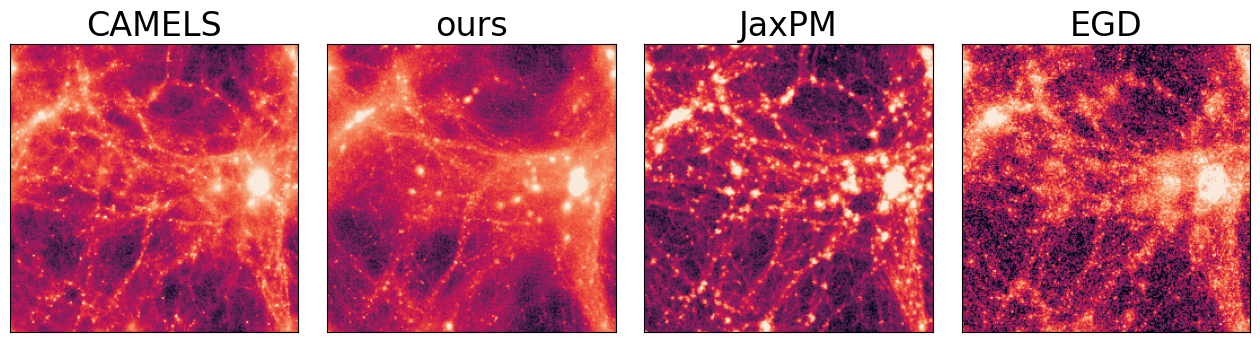

Traceback (most recent call last):
  File "/global/common/software/des/athomsen/flatiron/lib/python3.11/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/global/common/software/des/athomsen/flatiron/lib/python3.11/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/global/common/software/des/athomsen/flatiron/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/global/common/software/des/athomsen/flatiron/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/global/common/software/des/athomsen/flatiron/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/global/common/software/des/athomsen/flatiron/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.r

In [12]:
# Tunable layout parameters
subplot_size = 4        # size of each square subplot in inches
hspace = 0.1            # vertical spacing between rows
wspace = 0.1           # horizontal spacing between columns
cbar_width = 0.1       # width of vertical colorbar as fraction of figure
cbar_pad = 0.018         # padding between subplot and colorbar
fontsize = 24

nrows, ncols = 2, 4
fig = plt.figure(figsize=(ncols*subplot_size, nrows*subplot_size))
gs = GridSpec(nrows, ncols, figure=fig, hspace=hspace, wspace=wspace)

# Helper function to plot a row of fields with a shared vertical colorbar
def plot_row(poss, row_index, cmap, weights=None, percentile=(1,99), ylabel=None, plot_mesh=256):
    empty_mesh = jnp.zeros((plot_mesh,) * 2)

    # Varying particle counts (because of EGD)
    fields = []
    for i, pos in enumerate(poss):
        if weights is not None:
            weight = weights[i]
        else:
            weight = None
        field = cic_paint_2d(empty_mesh, pos[:,[1,2]] * (plot_mesh // mesh_per_dim), weight)
        fields.append(field)
    fields = jnp.stack(fields)
    
    vmin = jnp.percentile(fields, percentile[0])
    vmax = jnp.percentile(fields, percentile[1])
    print(f"vlim = [{vmin:.2f}, {vmax:.2f}]")
    norm = LogNorm(vmin=vmin, vmax=vmax)
    
    fields = jnp.where(fields == 0, vmin, fields)

    
    axs = []
    for j, field in enumerate(fields):
        ax = fig.add_subplot(gs[row_index, j])
        im = ax.imshow(field, norm=norm, cmap=cmap)
        ax.set_xticks([])
        ax.set_yticks([])
        if j == 0 and ylabel is not None:
            ax.set_ylabel(ylabel, fontsize=fontsize)
        axs.append(ax)

    # Colorbar: aligned with subplot height
    # cbar_ax = fig.add_axes([
    #     axs[-1].get_position().x1 + cbar_pad,
    #     axs[0].get_position().y0,
    #     cbar_width * subplot_size / fig.get_size_inches()[0],
    #     axs[0].get_position().height
    # ])
    # fig.colorbar(im, cax=cbar_ax, orientation="vertical")
    return axs
    
plot_gas_poss = [ref_gas_pos, hpm_gas_pos, pm_gas_pos, egd_gas_pos]
plot_gas_weights = [
    jnp.full(ref_gas_pos.shape[0], 1),
    jnp.full(hpm_gas_pos.shape[0], 1),
    jnp.full(pm_gas_pos.shape[0], 1),
    jnp.full(egd_gas_pos.shape[0], 1/gas_mass),
]
axs_top = plot_row(
    plot_gas_poss, 
    0, 
    cmap="rocket", 
    # ylabel=r"$\rho_\text{gas}$",
    weights=plot_gas_weights,
)

# plot_tot_poss = [
#     jnp.concat([ref_dm_pos, ref_gas_pos]), 
#     jnp.concat([hpm_dm_pos, hpm_gas_pos]), 
#     jnp.concat([pm_dm_pos, pm_gas_pos]), 
#     jnp.concat([egd_dm_pos, egd_gas_pos]), 
# ]
# plot_tot_weights = [
#     jnp.concat([jnp.full(ref_dm_pos.shape[0], dm_mass), jnp.full(ref_gas_pos.shape[0], gas_mass)]),
#     jnp.concat([jnp.full(hpm_dm_pos.shape[0], dm_mass), jnp.full(hpm_gas_pos.shape[0], gas_mass)]),
#     jnp.concat([jnp.full(pm_dm_pos.shape[0], dm_mass), jnp.full(pm_gas_pos.shape[0], gas_mass)]),
#     jnp.concat([jnp.full(egd_dm_pos.shape[0], 1), jnp.full(egd_gas_pos.shape[0], 1)]),
# ]
# axs_bottom = plot_row(
#     plot_tot_poss, 
#     1, 
#     cmap="mako", 
#     ylabel=r"$\rho_\text{tot} = \rho_\text{dm} + \rho_\text{gas}$", 
#     weights=plot_tot_weights
# )

# Column titles
titles = ["CAMELS", "ours", "JaxPM", "EGD"]
for ax, title in zip(axs_top, titles):
    ax.set_title(title, fontsize=fontsize)

# fig.savefig(f"plots/final_2d_fields_mesh={mesh_per_dim}.pdf", bbox_inches="tight", dpi=300)
fig.savefig(f"plots/final_2d_fields_mesh={mesh_per_dim}_gas.pdf", bbox_inches="tight", dpi=300)
plt.show()

vlim = [2.38, 354.27]


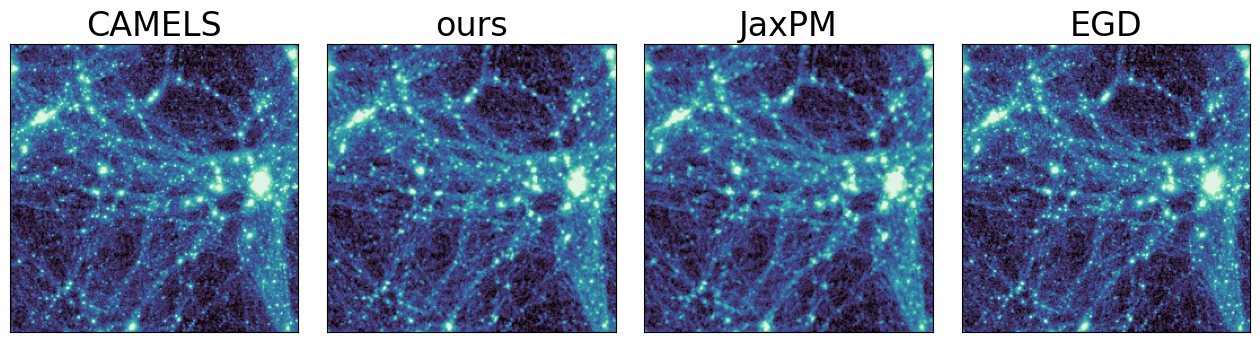

In [14]:
# Tunable layout parameters
subplot_size = 4        # size of each square subplot in inches
hspace = 0.1            # vertical spacing between rows
wspace = 0.1           # horizontal spacing between columns
cbar_width = 0.1       # width of vertical colorbar as fraction of figure
cbar_pad = 0.018         # padding between subplot and colorbar
fontsize = 24

nrows, ncols = 2, 4
fig = plt.figure(figsize=(ncols*subplot_size, nrows*subplot_size))
gs = GridSpec(nrows, ncols, figure=fig, hspace=hspace, wspace=wspace)

# Helper function to plot a row of fields with a shared vertical colorbar
def plot_row(poss, row_index, cmap, weights=None, percentile=(1,99), ylabel=None, plot_mesh=256):
    empty_mesh = jnp.zeros((plot_mesh,) * 2)

    # Varying particle counts (because of EGD)
    fields = []
    for i, pos in enumerate(poss):
        if weights is not None:
            weight = weights[i]
        else:
            weight = None
        field = cic_paint_2d(empty_mesh, pos[:,[1,2]] * (plot_mesh // mesh_per_dim), weight)
        fields.append(field)
    fields = jnp.stack(fields)
    
    vmin = jnp.percentile(fields, percentile[0])
    vmax = jnp.percentile(fields, percentile[1])
    print(f"vlim = [{vmin:.2f}, {vmax:.2f}]")
    norm = LogNorm(vmin=vmin, vmax=vmax)
    
    fields = jnp.where(fields == 0, vmin, fields)

    
    axs = []
    for j, field in enumerate(fields):
        ax = fig.add_subplot(gs[row_index, j])
        im = ax.imshow(field, norm=norm, cmap=cmap)
        ax.set_xticks([])
        ax.set_yticks([])
        if j == 0 and ylabel is not None:
            ax.set_ylabel(ylabel, fontsize=fontsize)
        axs.append(ax)

    # Colorbar: aligned with subplot height
    # cbar_ax = fig.add_axes([
    #     axs[-1].get_position().x1 + cbar_pad,
    #     axs[0].get_position().y0,
    #     cbar_width * subplot_size / fig.get_size_inches()[0],
    #     axs[0].get_position().height
    # ])
    # fig.colorbar(im, cax=cbar_ax, orientation="vertical")
    return axs
    
# plot_gas_poss = [ref_gas_pos, hpm_gas_pos, pm_gas_pos, egd_gas_pos]
# plot_gas_weights = [
#     jnp.full(ref_gas_pos.shape[0], 1),
#     jnp.full(hpm_gas_pos.shape[0], 1),
#     jnp.full(pm_gas_pos.shape[0], 1),
#     jnp.full(egd_gas_pos.shape[0], 1/gas_mass),
# ]
# axs_top = plot_row(
#     plot_gas_poss, 
#     0, 
#     cmap="rocket", 
#     ylabel=r"$\rho_\text{gas}$",
#     weights=plot_gas_weights,
# )

plot_dm_poss = [
    jnp.concat([ref_dm_pos]), 
    jnp.concat([hpm_dm_pos]), 
    jnp.concat([pm_dm_pos]), 
    jnp.concat([egd_dm_pos]), 
]
plot_dm_weights = [
    jnp.full(ref_dm_pos.shape[0], 1),
    jnp.full(hpm_dm_pos.shape[0], 1),
    jnp.full(pm_dm_pos.shape[0], 1),
    jnp.full(egd_dm_pos.shape[0], 1/dm_mass),
]
# axs_bottom = plot_row(
axs_top = plot_row(
    plot_dm_poss, 
    1, 
    cmap="mako", 
    # ylabel=r"$\rho_\text{dm}$", 
    weights=plot_dm_weights
)

# plot_tot_poss = [
#     jnp.concat([ref_dm_pos, ref_gas_pos]), 
#     jnp.concat([hpm_dm_pos, hpm_gas_pos]), 
#     jnp.concat([pm_dm_pos, pm_gas_pos]), 
#     jnp.concat([egd_dm_pos, egd_gas_pos]), 
# ]
# plot_tot_weights = [
#     jnp.concat([jnp.full(ref_dm_pos.shape[0], dm_mass), jnp.full(ref_gas_pos.shape[0], gas_mass)]),
#     jnp.concat([jnp.full(hpm_dm_pos.shape[0], dm_mass), jnp.full(hpm_gas_pos.shape[0], gas_mass)]),
#     jnp.concat([jnp.full(pm_dm_pos.shape[0], dm_mass), jnp.full(pm_gas_pos.shape[0], gas_mass)]),
#     jnp.concat([jnp.full(egd_dm_pos.shape[0], 1), jnp.full(egd_gas_pos.shape[0], 1)]),
# ]
# axs_bottom = plot_row(
#     plot_tot_poss, 
#     1, 
#     cmap="mako", 
#     ylabel=r"$\rho_\text{tot} = \rho_\text{dm} + \rho_\text{gas}$", 
#     weights=plot_tot_weights
# )

# Column titles
titles = ["CAMELS", "ours", "JaxPM", "EGD"]
for ax, title in zip(axs_top, titles):
    ax.set_title(title, fontsize=fontsize)

fig.savefig(f"plots/final_2d_fields_mesh={mesh_per_dim}_dm.pdf", bbox_inches="tight", dpi=300)

In [14]:
# # # Tunable layout parameters
# subplot_size = 4        # size of each square subplot in inches
# hspace = 0.1            # vertical spacing between rows
# wspace = 0.1           # horizontal spacing between columns
# cbar_width = 0.1       # width of vertical colorbar as fraction of figure
# cbar_pad = 0.018         # padding between subplot and colorbar

# nrows, ncols = 2, 4
# fig = plt.figure(figsize=(ncols*subplot_size, nrows*subplot_size))
# gs = GridSpec(nrows, ncols, figure=fig, hspace=hspace, wspace=wspace)

# # Helper function to plot a row of fields with a shared vertical colorbar
# def plot_row(fields, row_index, cmap, percentile=(1,99), ylabel=None):
#     fields = jnp.stack(fields)
#     fields = fields.sum(axis=1)
    
#     # Stack fields for computing vmin/vmax
#     vmin = jnp.percentile(fields, percentile[0])
#     vmax = jnp.percentile(fields, percentile[1])
#     print(f"vlim = [{vmin:.2f}, {vmax:.2f}]")
#     norm = LogNorm(vmin=vmin, vmax=vmax)

#     axs = []
#     for j, field in enumerate(fields):
#         ax = fig.add_subplot(gs[row_index, j])
#         im = ax.imshow(field, norm=norm, cmap=cmap)
#         # im = ax.pcolormesh(field, norm=norm, cmap=cmap, shading="nearest")
#         ax.set_xticks([])
#         ax.set_yticks([])
#         if j == 0 and ylabel is not None:
#             ax.set_ylabel(ylabel, fontsize=20)
#         axs.append(ax)

#     # Colorbar: aligned with subplot height
#     cbar_ax = fig.add_axes([
#         axs[-1].get_position().x1 + cbar_pad,
#         axs[0].get_position().y0,
#         cbar_width * subplot_size / fig.get_size_inches()[0],
#         axs[0].get_position().height
#     ])
#     fig.colorbar(im, cax=cbar_ax, orientation="vertical")
#     return axs
    
# fields_gas = [ref_rho_gas, hpm_rho_gas, pm_rho_gas, egd_rho_gas]
# # fields_gas = [ref_rho_gas, egd_rho_gas, pm_rho_gas, hpm_rho_gas]
# axs_top = plot_row(fields_gas, 0, cmap="rocket", ylabel=r"$\rho_\text{gas}$")

# fields_tot = [ref_rho_tot, hpm_rho_tot, pm_rho_tot, egd_rho_tot]
# # fields_tot = [ref_rho_tot, egd_rho_tot, pm_rho_tot, hpm_rho_tot]
# axs_bottom = plot_row(fields_tot, 1, cmap="mako", ylabel=r"$\rho_\text{tot} = \rho_\text{dm} + \rho_\text{gas}$")

# # Column titles
# titles = ["CAMELS", "this work", "JaxPM", "EGD"]
# # titles = ["CAMELS", "EGD", "JaxPM", "JaxHPM"]
# for ax, title in zip(axs_top, titles):
#     ax.set_title(title, fontsize=20)

# fig.savefig(f"plots/final_fields_mesh={mesh_per_dim}.pdf", bbox_inches="tight", dpi=300)
# plt.show()

# two-point

In [11]:
p_spectrum = lambda delta: power_spectrum(
    compensate_cic(delta),
    boxsize=np.array([25.] * 3),
    kmin=np.pi / 25.,
    dk=2 * np.pi / 25.
)

x_spectrum = lambda delta_1, delta_2: cross_correlation_coefficients(
    compensate_cic(delta_1),
    compensate_cic(delta_2),
    boxsize=np.array([25.] * 3),
    kmin=np.pi / 25.,
    dk=2 * np.pi / 25.
)

# gas
ref_delta_gas = ref_rho_gas / ref_rho_gas.mean() - 1
pm_delta_gas = pm_rho_gas / pm_rho_gas.mean() - 1
hpm_delta_gas = hpm_rho_gas / hpm_rho_gas.mean() - 1
egd_delta_gas = egd_rho_gas / egd_rho_gas.mean() - 1

k, ref_pk_gas = p_spectrum(ref_delta_gas)
_, pm_pk_gas = p_spectrum(pm_delta_gas)
_, hpm_pk_gas = p_spectrum(hpm_delta_gas)
_, egd_pk_gas = p_spectrum(egd_delta_gas)

_, ref_xpk_gas = x_spectrum(ref_delta_gas, ref_delta_gas)
_, pm_xpk_gas = x_spectrum(pm_delta_gas, ref_delta_gas)
_, hpm_xpk_gas = x_spectrum(hpm_delta_gas, ref_delta_gas)
_, egd_xpk_gas = x_spectrum(egd_delta_gas, ref_delta_gas)

# dm
ref_delta_dm = ref_rho_dm / ref_rho_dm.mean() - 1
pm_delta_dm = pm_rho_dm / pm_rho_dm.mean() - 1
hpm_delta_dm = hpm_rho_dm / hpm_rho_dm.mean() - 1
egd_delta_dm = egd_rho_dm / egd_rho_dm.mean() - 1

k, ref_pk_dm = p_spectrum(ref_delta_dm)
_, pm_pk_dm = p_spectrum(pm_delta_dm)
_, hpm_pk_dm = p_spectrum(hpm_delta_dm)
_, egd_pk_dm = p_spectrum(egd_delta_dm)

_, ref_xpk_dm = x_spectrum(ref_delta_dm, ref_delta_dm)
_, pm_xpk_dm = x_spectrum(pm_delta_dm, ref_delta_dm)
_, hpm_xpk_dm = x_spectrum(hpm_delta_dm, ref_delta_dm)
_, egd_xpk_dm = x_spectrum(egd_delta_dm, ref_delta_dm)

# total
ref_delta_tot = ref_rho_tot / ref_rho_tot.mean() - 1
pm_delta_tot = pm_rho_tot / pm_rho_tot.mean() - 1
hpm_delta_tot = hpm_rho_tot / hpm_rho_tot.mean() - 1
egd_delta_tot = egd_rho_tot / egd_rho_tot.mean() - 1

k, ref_pk_tot = p_spectrum(ref_delta_tot)
_, pm_pk_tot = p_spectrum(pm_delta_tot)
_, hpm_pk_tot = p_spectrum(hpm_delta_tot)
_, egd_pk_tot = p_spectrum(egd_delta_tot)

_, ref_xpk_tot = x_spectrum(ref_delta_tot, ref_delta_tot)
_, pm_xpk_tot = x_spectrum(pm_delta_tot, ref_delta_tot)
_, hpm_xpk_tot = x_spectrum(hpm_delta_tot, ref_delta_tot)
_, egd_xpk_tot = x_spectrum(egd_delta_tot, ref_delta_tot)

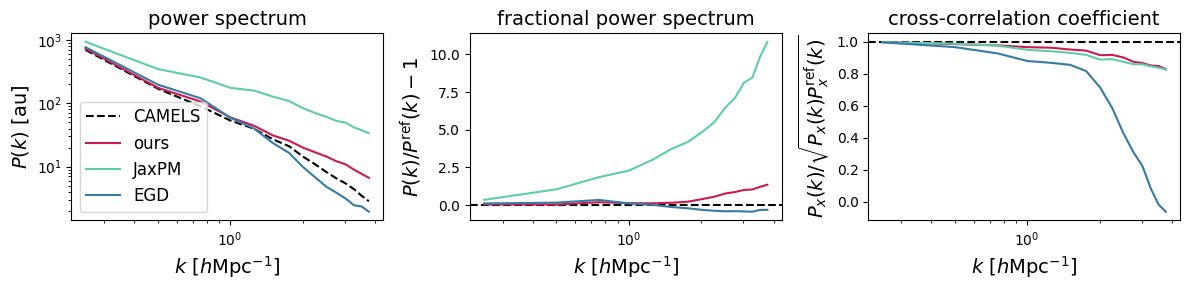

In [12]:
# colors = sns.color_palette(["#5eccab", "#e6a176", "#00678a"])
# colors = sns.color_palette("colorblind")

# pm_color = sns.color_palette("rocket", 3)[-1]
# hpm_color = sns.color_palette("rocket", 3)[0]
# egd_color = sns.color_palette("mako", 1)[0]

pm_color = "#5eccab" 
hpm_color = sns.color_palette("rocket", 1)[0]
egd_color = sns.color_palette("mako", 1)[0]
colors = [pm_color, hpm_color, egd_color]

inds = k < 4.0
xlabel = r"$k$ [$h \text{Mpc}^{-1}$]"
fontsize = 14

fig, ax = plt.subplots(figsize=(12, 3), ncols=3, nrows=1, sharex=True)

ax[0].plot(k[inds], ref_pk_gas[inds], label="CAMELS", color="k", linestyle="--")
ax[0].plot(k[inds], hpm_pk_gas[inds], label="ours", color=colors[1])
ax[0].plot(k[inds], pm_pk_gas[inds], label="JaxPM", color=colors[0])
ax[0].plot(k[inds], egd_pk_gas[inds], label="EGD", color=colors[2])
ax[0].set_xlabel(xlabel, fontsize=fontsize)
ax[0].set_ylabel(r"$P(k)$ [au]", fontsize=fontsize)
ax[0].set_title("power spectrum", fontsize=fontsize)

ax[0].legend(loc="lower left", fontsize=fontsize-2)
ax[0].set(xscale="log", yscale="log")

ax[1].axhline(0, color="k", linestyle="--")
ax[1].plot(k[inds], hpm_pk_gas[inds] / ref_pk_gas[inds] - 1, color=colors[1])
ax[1].plot(k[inds], pm_pk_gas[inds] / ref_pk_gas[inds] - 1, color=colors[0])
ax[1].plot(k[inds], egd_pk_gas[inds] / ref_pk_gas[inds] - 1, color=colors[2])
ax[1].set_xlabel(xlabel, fontsize=fontsize)
ax[1].set_ylabel(r"$P(k)/P^\text{ref}(k) - 1$", fontsize=fontsize)
ax[1].set_title("fractional power spectrum", fontsize=fontsize)

ax[2].axhline(1, color="k", linestyle="--")
ax[2].plot(k[inds], hpm_xpk_gas[inds] / np.sqrt(hpm_pk_gas[inds] * ref_pk_gas[inds]), color=colors[1])
ax[2].plot(k[inds], pm_xpk_gas[inds] / np.sqrt(pm_pk_gas[inds] * ref_pk_gas[inds]), color=colors[0])
ax[2].plot(k[inds], egd_xpk_gas[inds] / np.sqrt(egd_pk_gas[inds] * ref_pk_gas[inds]), color=colors[2])
ax[2].set_xlabel(xlabel, fontsize=fontsize)
ax[2].set_ylabel(r"$P_x(k) / \sqrt{P_x(k) P_x^\text{ref}(k)}$", fontsize=fontsize)
ax[2].set_title("cross-correlation coefficient", fontsize=fontsize)

fig.tight_layout()

fig.savefig(f"plots/final_2pt_mesh={mesh_per_dim}.pdf", bbox_inches="tight", dpi=300)

In [106]:
# # colors = sns.color_palette(["#984464", "#e6a176", "#00678a"])

# pm_color = sns.color_palette("rocket", 3)[-1]
# hpm_color = sns.color_palette("rocket", 3)[0]
# egd_color = sns.color_palette("mako", 1)[0]
# colors = [pm_color, hpm_color, egd_color]

# inds = k < 4.0

# fig, ax = plt.subplots(figsize=(8, 4), ncols=2, nrows=2, sharex=True)

# ax[0, 0].plot(k[inds], pm_pk_gas[inds], label="JaxPM", color=colors[0])
# ax[0, 0].plot(k[inds], hpm_pk_gas[inds], label="ours", color=colors[1])
# ax[0, 0].plot(k[inds], egd_pk_gas[inds], label="EGD", color=colors[2])
# ax[0, 0].plot(k[inds], ref_pk_gas[inds], label="CAMELS", color="k", linestyle="--")
# ax[0,0].set(yscale="log", ylabel=r"$P(k)$")
# ax[0,0].legend(loc="lower left")

# # ax[0,0].set(xscale="log", xlim=(k.min(), 4.0))
# ax[0,0].set(xscale="log")

# ax[1,0].plot(k[inds], pm_pk_gas[inds]/ref_pk_gas[inds] - 1, color=colors[0])
# ax[1,0].plot(k[inds], hpm_pk_gas[inds]/ref_pk_gas[inds] - 1, color=colors[1])
# ax[1,0].plot(k[inds], egd_pk_gas[inds]/ref_pk_gas[inds] - 1, color=colors[2])
# ax[1,0].axhline(0, color="k", linestyle="--",)
# ax[1,0].set(ylabel=r"$P(k)/P^\text{ref}(k) - 1$")

# ax[1].plot(k, pm_xpk_gas/np.sqrt(pm_pk_gas*ref_pk_gas), color=colors[0])
# ax[1].plot(k, hpm_xpk_gas/np.sqrt(hpm_pk_gas*ref_pk_gas), color=colors[1])
# ax[1].plot(k, egd_xpk_gas/np.sqrt(egd_pk_gas*ref_pk_gas), color=colors[2])
# ax[1].axhline(1, color="k", linestyle="--")

# # ax[1].set(xscale="log")

[None]

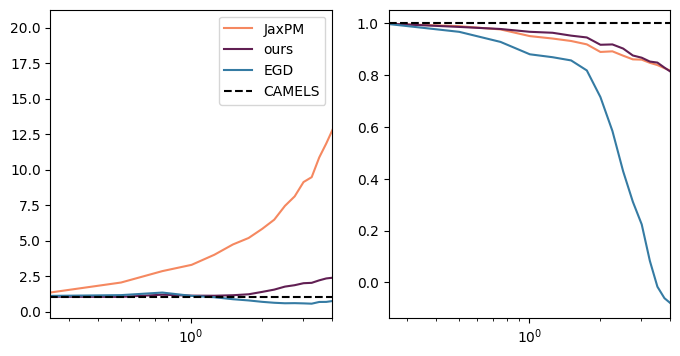

In [69]:
# colors = sns.color_palette(["#984464", "#e6a176", "#00678a"])

pm_color = sns.color_palette("rocket", 3)[-1]
hpm_color = sns.color_palette("rocket", 3)[0]
egd_color = sns.color_palette("mako", 1)[0]
colors = [pm_color, hpm_color, egd_color]

fig, ax = plt.subplots(figsize=(8, 4), ncols=2, sharex=True)

ax[0].plot(k, pm_pk_gas/ref_pk_gas, label="JaxPM", color=colors[0])
ax[0].plot(k, hpm_pk_gas/ref_pk_gas, label="ours", color=colors[1])
ax[0].plot(k, egd_pk_gas/ref_pk_gas, label="EGD", color=colors[2])
ax[0].axhline(1, linestyle="--", label="CAMELS", color="k")
ax[0].set(xlim=(k.min(), 4.0))

# ax[0].set(xscale="log", ylim=(0, 1.5))
ax[0].set(xscale="log")
ax[0].legend()

ax[1].plot(k, pm_xpk_gas/np.sqrt(pm_pk_gas*ref_pk_gas), color=colors[0])
ax[1].plot(k, hpm_xpk_gas/np.sqrt(hpm_pk_gas*ref_pk_gas), color=colors[1])
ax[1].plot(k, egd_xpk_gas/np.sqrt(egd_pk_gas*ref_pk_gas), color=colors[2])
ax[1].axhline(1, color="k", linestyle="--")

ax[1].set(xscale="log")

In [63]:
k

array([ 0.25132741,  0.50265482,  0.75398224,  1.00530965,  1.25663706,
        1.50796447,  1.75929189,  2.0106193 ,  2.26194671,  2.51327412,
        2.76460154,  3.01592895,  3.26725636,  3.51858377,  3.76991118,
        4.0212386 ,  4.27256601,  4.52389342,  4.77522083,  5.02654825,
        5.27787566,  5.52920307,  5.78053048,  6.03185789,  6.28318531,
        6.53451272,  6.78584013,  7.03716754,  7.28849496,  7.53982237,
        7.79114978,  8.04247719,  8.29380461,  8.54513202,  8.79645943,
        9.04778684,  9.29911425,  9.55044167,  9.80176908, 10.05309649,
       10.3044239 , 10.55575132, 10.80707873, 11.05840614, 11.30973355,
       11.56106097, 11.81238838, 12.06371579, 12.3150432 , 12.56637061,
       12.81769803, 13.06902544, 13.32035285, 13.57168026, 13.82300768,
       14.07433509, 14.3256625 , 14.57698991, 14.82831732, 15.07964474,
       15.33097215, 15.58229956, 15.83362697])

[None]

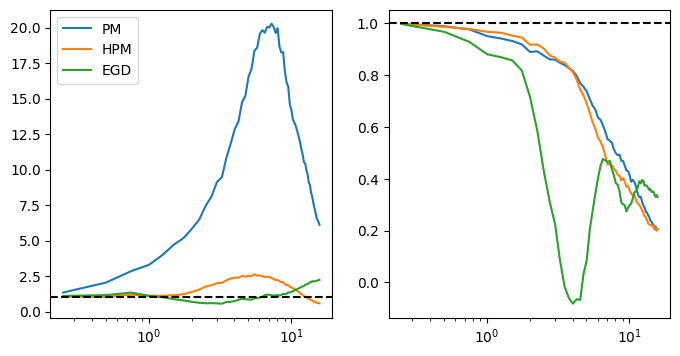

In [16]:
ref_delta_gas = ref_rho_gas / ref_rho_gas.mean() - 1
pm_delta_gas = pm_rho_gas / pm_rho_gas.mean() - 1
hpm_delta_gas = hpm_rho_gas / hpm_rho_gas.mean() - 1
egd_delta_gas = egd_rho_gas / egd_rho_gas.mean() - 1

k, ref_pk_gas = p_spectrum(ref_delta_gas)
_, pm_pk_gas = p_spectrum(pm_delta_gas)
_, hpm_pk_gas = p_spectrum(hpm_delta_gas)
_, egd_pk_gas = p_spectrum(egd_delta_gas)

_, ref_xpk_gas = x_spectrum(ref_delta_gas, ref_delta_gas)
_, pm_xpk_gas = x_spectrum(pm_delta_gas, ref_delta_gas)
_, hpm_xpk_gas = x_spectrum(hpm_delta_gas, ref_delta_gas)
_, egd_xpk_gas = x_spectrum(egd_delta_gas, ref_delta_gas)

fig, ax = plt.subplots(figsize=(8, 4), ncols=2)

ax[0].plot(k, pm_pk_gas/ref_pk_gas, label="PM")
ax[0].plot(k, hpm_pk_gas/ref_pk_gas, label="HPM")
ax[0].plot(k, egd_pk_gas/ref_pk_gas, label="EGD")
ax[0].axhline(1, color="k", linestyle="--")

# ax[0].set(xscale="log", ylim=(0, 1.5))
ax[0].set(xscale="log")
ax[0].legend()

ax[1].plot(k, pm_xpk_gas/np.sqrt(pm_pk_gas*ref_pk_gas), label="PM")
ax[1].plot(k, hpm_xpk_gas/np.sqrt(hpm_pk_gas*ref_pk_gas), label="HPM")
ax[1].plot(k, egd_xpk_gas/np.sqrt(egd_pk_gas*ref_pk_gas), label="EGD")
ax[1].axhline(1, color="k", linestyle="--")

ax[1].set(xscale="log")

[None]

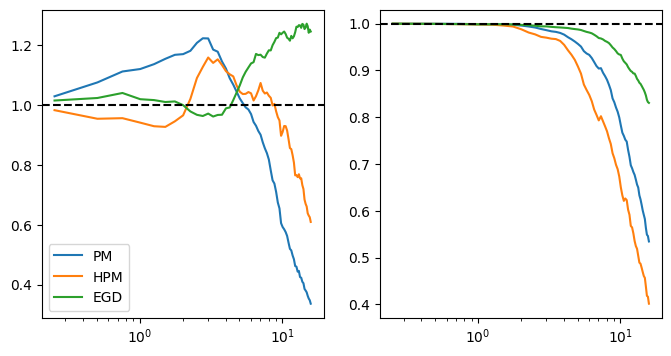

In [17]:
# ref_delta_tot = ref_rho_tot / ref_rho_tot.mean() - 1
# pm_delta_tot = pm_rho_tot / pm_rho_tot.mean() - 1
# hpm_delta_tot = hpm_rho_tot / hpm_rho_tot.mean() - 1
# egd_delta_tot = egd_rho_tot / egd_rho_tot.mean() - 1

# k, ref_pk_tot = p_spectrum(ref_delta_tot)
# _, pm_pk_tot = p_spectrum(pm_delta_tot)
# _, hpm_pk_tot = p_spectrum(hpm_delta_tot)
# _, egd_pk_tot = p_spectrum(egd_delta_tot)

# _, ref_xpk_tot = x_spectrum(ref_delta_tot, ref_delta_tot)
# _, pm_xpk_tot = x_spectrum(pm_delta_tot, ref_delta_tot)
# _, hpm_xpk_tot = x_spectrum(hpm_delta_tot, ref_delta_tot)
# _, egd_xpk_tot = x_spectrum(egd_delta_tot, ref_delta_tot)

# fig, ax = plt.subplots(figsize=(8, 4), ncols=2)

# ax[0].plot(k, pm_pk_tot/ref_pk_tot, label="PM")
# ax[0].plot(k, hpm_pk_tot/ref_pk_tot, label="HPM")
# ax[0].plot(k, egd_pk_tot/ref_pk_tot, label="EGD")
# ax[0].axhline(1, color="k", linestyle="--")

# # ax[0].set(xscale="log", ylim=(0, 1.5))
# ax[0].set(xscale="log")
# ax[0].legend()

# ax[1].plot(k, pm_xpk_tot/np.sqrt(pm_pk_tot*ref_pk_tot), label="PM")
# ax[1].plot(k, hpm_xpk_tot/np.sqrt(hpm_pk_tot*ref_pk_tot), label="HPM")
# ax[1].plot(k, egd_xpk_tot/np.sqrt(egd_pk_tot*ref_pk_tot), label="EGD")
# ax[1].axhline(1, color="k", linestyle="--")

# ax[1].set(xscale="log")

# pressure

In [18]:
scale = scales[i1]
ref_gas_pos = gas_poss[i1]
ref_gas_vel = gas_vels[i1]
ref_gas_P = vali_dict["gas_Ps"][i1]

In [19]:
ref_N_gas = cic_paint(jnp.zeros(mesh_shape), ref_gas_pos, 1)
ref_gas_N = cic_read(ref_N_gas, ref_gas_pos)
ref_P_gas = cic_paint(jnp.zeros(mesh_shape), ref_gas_pos, ref_gas_P/ref_gas_N)

In [20]:
hpm_N_gas = cic_paint(jnp.zeros(mesh_shape), hpm_gas_pos, 1)
hpm_gas_N = cic_read(hpm_N_gas, hpm_gas_pos)

hpm_rho_gas = gas_mass * hpm_N_gas
hpm_gas_rho = gas_mass * hpm_gas_N

gas_inputs = hpm.get_hpm_inputs(
    scale,
    hpm_gas_pos,
    hpm_gas_vel,
    hpm_gas_rho,
    hpm_rho_gas,
    hpm_gas_N,
    mesh_shape,
    return_vel=True,
    return_field=False,
)
gas_preds = pressure_model(gas_inputs, training=False)
hpm_gas_P = 10 ** jnp.squeeze(gas_preds)

hpm_P_gas = cic_paint(jnp.zeros(mesh_shape), hpm_gas_pos, hpm_gas_P/hpm_gas_N)

In [21]:
hpm_P_gas_k = jnp.fft.rfftn(hpm_P_gas)
kvec = fftk(mesh_shape)
k = jnp.sqrt(sum((ki / jnp.pi) ** 2 for ki in kvec))
hpm_P_gas_k += hpm_P_gas_k * pressure_model.k_model(k, jnp.atleast_1d(1.0))
hpm_P_gas_filtered = jnp.fft.irfftn(hpm_P_gas_k)

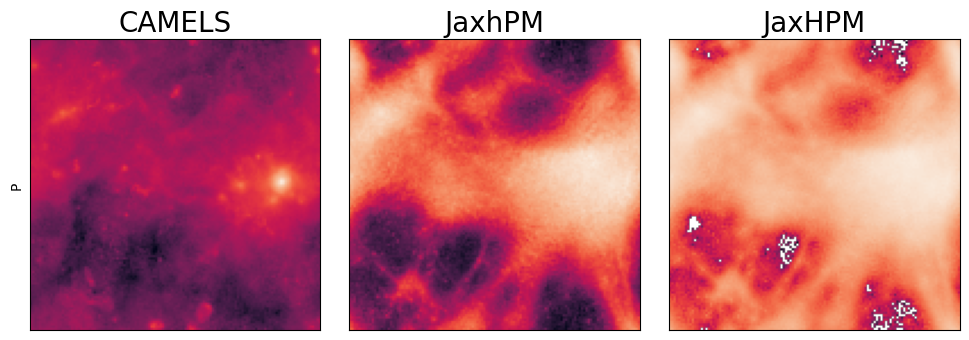

In [22]:
i = -1
ncols = 3
subplot_size = 4      # size of each square subplot
wspace = 0.1         # horizontal spacing between subplots

cmap = sns.color_palette("rocket", as_cmap=True)

fig = plt.figure(figsize=(ncols*subplot_size, subplot_size))
gs = GridSpec(1, ncols, figure=fig, wspace=wspace)

fields = [ref_P_gas, hpm_P_gas, hpm_P_gas_filtered]
titles = ["CAMELS", "JaxhPM", "JaxHPM"]

for i in range(ncols):
    ax = fig.add_subplot(gs[0, i])
    field = fields[i].sum(axis=0)
    im = ax.imshow(field, cmap=cmap, norm="log")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(titles[i], fontsize=20)

    if i == 0:
        ax.set_ylabel("P")

# fig.savefig(f"plots/hpm_inputs_mesh={mesh_per_dim}.pdf", bbox_inches="tight", dpi=300)

# position loss

In [23]:
pressure_loss = ParticleLoss(
    mesh_per_dim,
    w_pos=1.0,
    w_vel=0.0,
    w_cls=0.0,
    w_cross=0.0,
    w_snapshot=0.0,
    # cutoff_quantile=0.95,
)

In [24]:
pm_loss = pressure_loss(
    pm_gas_pos,
    ref_poss=ref_gas_pos,
    snapshot_mean=False,
    particle_mean=False,
)

hpm_loss = pressure_loss(
    hpm_gas_pos,
    ref_poss=ref_gas_pos,
    snapshot_mean=False,
    particle_mean=False,
)

all_loss = jnp.stack([pm_loss, hpm_loss])

Using particle loss
w_pos = 1.0, loss = huber, scale = 8.0
Using particle loss
w_pos = 1.0, loss = huber, scale = 8.0


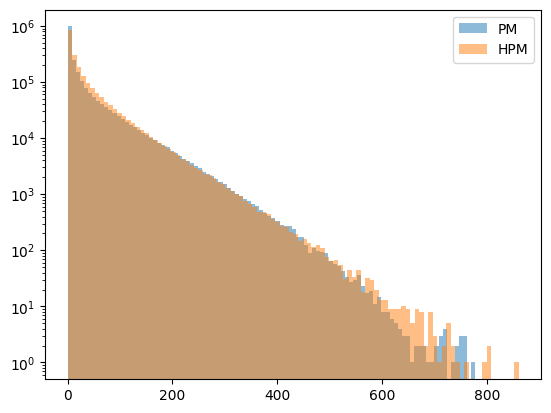

In [25]:
fig, ax = plt.subplots()

ax.hist(pm_loss, label="PM", alpha=0.5, bins=100, log=True)
ax.hist(hpm_loss, label="HPM", alpha=0.5, bins=100)
ax.legend()

[Text(0.5, 0.92, 'HPM gas displacement')]

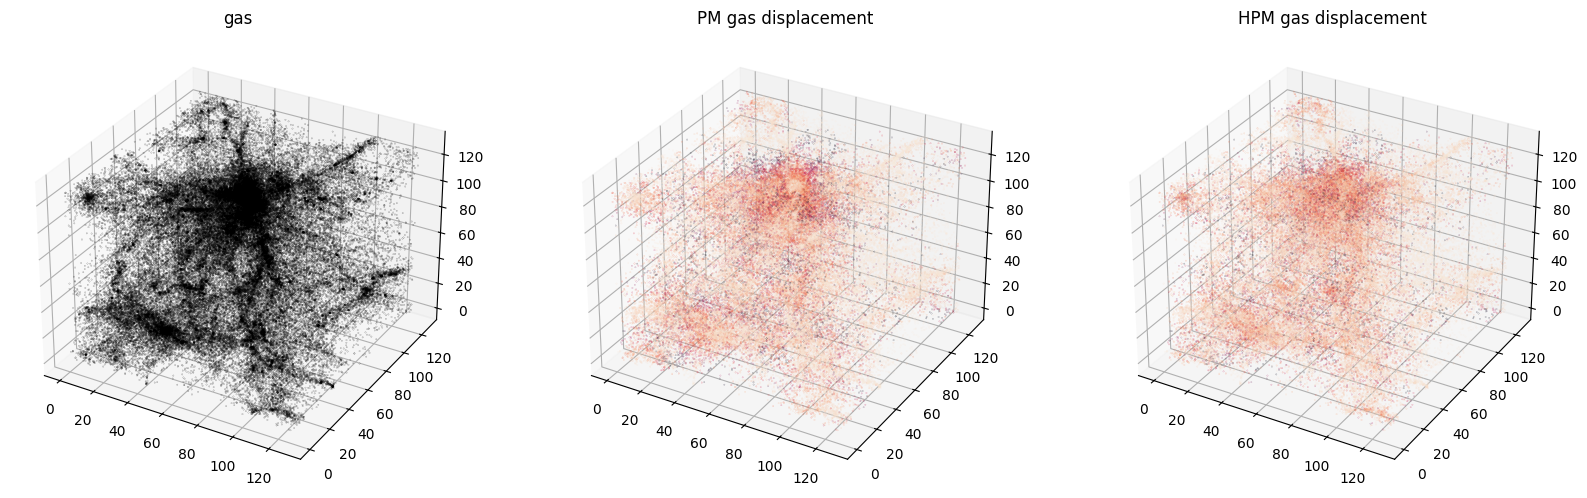

In [26]:
i = np.random.choice(np.arange(parts_per_dim**3), 100_000, replace=False)
vmin = jnp.percentile(all_loss, 1)
vmax = jnp.percentile(all_loss, 99)

fig, ax = plt.subplots(figsize=(20, 6), ncols=3, subplot_kw={"projection": "3d"})

im = ax[0].scatter(
    ref_gas_pos[i, 0], ref_gas_pos[i, 1], ref_gas_pos[i, 2],
    c="k", marker="o", alpha=1.0, s=0.01,
)
ax[0].set(title="gas")

im = ax[1].scatter(
    ref_gas_pos[i, 0], ref_gas_pos[i, 1], ref_gas_pos[i, 2],
    c=pm_loss[i], cmap="rocket_r", marker="o", alpha=1.0, s=0.01, vmin=vmin, vmax=vmax,
)
ax[1].set(title="PM gas displacement")

im = ax[2].scatter(
    ref_gas_pos[i, 0], ref_gas_pos[i, 1], ref_gas_pos[i, 2],
    c=hpm_loss[i], cmap="rocket_r", marker="o", alpha=1.0, s=0.01, vmin=vmin, vmax=vmax,
)
ax[2].set(title="HPM gas displacement")